# The Sky of al-Jawza Inscribed
### *A grouped celestial quipu — 62 stars, 10 asterism — woven into the chain through the apocryphal hand*

<div>
<img src="images/al_jawza_desert.png" width="900"/>
</div>

> *The Bedouin named the stars before the Greeks. al-Jawza, the slain giantess. al-Thurayya, the chandelier. al-Dabarān, the follower. Suhayl, the murderer-husband fled to the southern horizon — rising briefly each evening, never permitted to climb back into the central sky.*
> &mdash; after the Anwā' tradition, attested by al-Sufi (964 CE) and reaffirmed by Lane's *Manners and Customs of the Modern Egyptians* (1836)

> *Hyperstition is the experimental (techno-)science of self-fulfilling prophecies. Successful hyperstitions turn themselves real.*
> &mdash; Nick Land / CCRU


Three figures by lamplight on the desert sand. The elder traces an embroidered constellation on an unrolled rug; the two younger watch where her finger points to the matching pattern in the sky overhead. Suhayl flickers red on the southern horizon — the husband-murderer fled, never returning. The Milky Way bands the sky. The Pleiades westward, the Hyades following.

Tonight the same figure goes into the chain. The diamond runs through apocrypha — single hand, single key, five orphaned tails consolidated as the seed. The cabeza carries the header; four cuerpos carry the body. The bytes that follow declare it: a celestial figure, grouped, star-kind, reverence tone.


In [18]:
import warnings
warnings.filterwarnings('ignore', message='urllib3 v2 only supports OpenSSL')

import sys, json, hashlib, time
sys.path.insert(0, '/Users/.../Desktop/Colegio_Invisible')
import cryptos
import pandas as pd
import colegio_tools as ct
from colegio_tools import mk_opreturn, _txid_of_serial, serialize
doge = cryptos.Doge()
TIP = 5_000_000   # 0.05 DOGE per knot — project standard


## The Hand
Apocrypha. Single-key. One person at the lamp.


In [19]:
APOCRYPHA_PATH = '../../cinv/llaves/mi_prv.enc'
EXPECTED_ADDRESS = 'D6zKNnkupqRbkB9p5rwix8QiobQWJazjyX'

enc = open(APOCRYPHA_PATH, 'rb').read()
priv_hex = ct.import_privKey_from_bytes(enc, '').to_hex()[2:]
addr     = doge.privtoaddr(priv_hex)
assert addr == EXPECTED_ADDRESS
print(f'address: {addr}')


address: D6zKNnkupqRbkB9p5rwix8QiobQWJazjyX


## The Sky — pre-built payload
The inscription bytes were constructed yesterday via `build_grouped_celestial_quipu` over 62 SIMBAD-J2000 star coordinates and 10 named groups. We load them here and read the header byte-by-byte to see what they declare.


In [21]:
payload = json.load(open('../inscriptions_ready/orion_lepus_monoceros_payload.json'))
header_bytes = bytes.fromhex(payload['header_hex'])
body_bytes   = bytes.fromhex(payload['body_hex'])

print(f'Header ({len(header_bytes)} bytes):  {header_bytes.hex()}')
print()
print('Byte-by-byte:')
print(f'  c1dd 0001   magic + protocol version 0.1  (every quipu begins with this)')
print(f'  {header_bytes[4]:02x}          type byte — 0xce = celestial')
print(f'  {header_bytes[5]:02x}          tone byte — 0xff = reverence (talks about the dead)')
print(f'  {header_bytes[6]:02x}          kind byte — 0x{header_bytes[6]:02x} =')
print(f'                 bit 7 (0x80) GROUPED_FLAG set → groups block follows the points block')
print(f'                 bits 0..6    figure-kind 0x{header_bytes[6]&0x7f:02x} → star coordinates (RA, dec) at J2000.0')
print(f'  {header_bytes[7]:02x}          K = {header_bytes[7]} points (stars in the figure)')
print(f'  {header_bytes[8]:02x}          T = {header_bytes[8]} bytes of title text following')
print(f'  ...         title text: {header_bytes[9:].decode("utf-8")!r}')
print()
print(f'Body ({len(body_bytes)} bytes): K point records ({payload["n_stars"]} stars × ~16 B each),')
print(f'                      then the groups block ({len(payload["groups"])} named groups).')
print()
print(f'Groups in this figure (IAU canonical names — Arabic equivalents live in a separate translation quipu):')
for g in payload['groups']:
    print(f'    {g["name"]:18s}  {len(g["point_indices"]):2d} pts  {len(g["lines"]):2d} lines')


Header (28 bytes):  c1dd0001ceff813e1354686520536b79206f6620616c2d4a61777a61

Byte-by-byte:
  c1dd 0001   magic + protocol version 0.1  (every quipu begins with this)
  ce          type byte — 0xce = celestial
  ff          tone byte — 0xff = reverence (talks about the dead)
  81          kind byte — 0x81 =
                 bit 7 (0x80) GROUPED_FLAG set → groups block follows the points block
                 bits 0..6    figure-kind 0x01 → star coordinates (RA, dec) at J2000.0
  3e          K = 62 points (stars in the figure)
  13          T = 19 bytes of title text following
  ...         title text: 'The Sky of al-Jawza'

Body (1253 bytes): K point records (62 stars × ~16 B each),
                      then the groups block (10 named groups).

Groups in this figure (IAU canonical names — Arabic equivalents live in a separate translation quipu):
    Winter Triangle      3 pts   3 lines
    Orion               10 pts  12 lines
    Taurus              10 pts   9 lines
    Pleiades     

## The Strands
Header strand carries the cabeza — type, tone, title, group count. Body splits into four cuerpos: points block then groups block, sharded.


In [22]:
N_BODY_STRANDS = 4
chunk = len(body_bytes) // N_BODY_STRANDS
extra = len(body_bytes) %  N_BODY_STRANDS
body_parts, i = [], 0
for k in range(N_BODY_STRANDS):
    sz = chunk + (1 if k < extra else 0)
    body_parts.append(body_bytes[i:i+sz]); i += sz
strand_payloads = [header_bytes] + body_parts
for j, p in enumerate(strand_payloads):
    print(f'  strand {j} ({"cabeza" if j==0 else "cuerpo"}): {len(p)} B → {max(1,(len(p)+79)//80)} knots')


  strand 0 (cabeza): 28 B → 1 knots
  strand 1 (cuerpo): 314 B → 4 knots
  strand 2 (cuerpo): 313 B → 4 knots
  strand 3 (cuerpo): 313 B → 4 knots
  strand 4 (cuerpo): 313 B → 4 knots


## The Five Tails
Apocrypha holds five orphaned UTXOs from an earlier (Bowie) inscription that ran here in error. We absorb all five as inputs into this new diamond's root tx — the inscription doubles as consolidation. After the join, apocrypha holds one clean UTXO.


In [23]:
utxos = ct.get_address_utxos(addr)
print(f'  apocrypha UTXOs to consume: {len(utxos)}')
total_input_value = 0
seed_inputs = []
for u in utxos:
    seed_inputs.append({
        'output': f"{u['txid']}:{u['vout']}",
        'value':  int(round(u['amount'] * 100_000_000)),
    })
    total_input_value += seed_inputs[-1]['value']
print(f'  total input value: {total_input_value/1e8:.4f} DOGE')


  apocrypha UTXOs to consume: 5
  total input value: 15.7500 DOGE


## Phase I — The Sky Unrolls
A single transaction takes all five tails and divides their sum into five outputs back to apocrypha. Each output becomes the seed for one strand. The lamp burns. The rug unrolls.


In [24]:
n = len(strand_payloads)
ROOT_FEE = TIP
per = (total_input_value - ROOT_FEE) // n
remainder = (total_input_value - ROOT_FEE) - per * n
strand_seeds = [per] * n
strand_seeds[0] += remainder   # any leftover satoshis go to the cabeza

root_outputs = [{'value': s, 'address': addr} for s in strand_seeds]
root_tx = doge.mktx(seed_inputs, root_outputs)
doge.signall(root_tx, priv_hex)
root_hex   = cryptos.serialize(root_tx)
root_txid  = _txid_of_serial(root_hex)
broadcast  = ct.rpc_request('sendrawtransaction', [root_hex])
assert broadcast == root_txid
print(f'root txid: {root_txid}')
print(f'  {len(seed_inputs)} inputs → {n} outputs back to apocrypha')
print(f'  each seed: {strand_seeds[0]/1e8:.4f} (cabeza) / {strand_seeds[1]/1e8:.4f} (cuerpos)')


root txid: 4e53bb26a432cc27996dda141b6fee5ac7a64d429394b307a08dd49cc7ec15cc
  5 inputs → 5 outputs back to apocrypha
  each seed: 3.1400 (cabeza) / 3.1400 (cuerpos)


## Phase II — The Constellations Trace Themselves
From each root output, a chain descends. Every knot: a self-send back to apocrypha, single signature, eighty bytes of star-data deposited in `OP_RETURN`. `CadenaAtom` precomputes the entire descent before any broadcast — every txid known in advance, every signature in place. *The pattern existed inside before we ever looked up to confirm it.*


In [25]:
strands = []
for si, payload in enumerate(strand_payloads):
    cad = ct.CadenaAtom(
        prvkey=priv_hex,
        data=payload,
        utxo_dct={'output': f'{root_txid}:{si}', 'value': strand_seeds[si]},
        tip=TIP,
    )
    cad.precompute()
    strands.append(cad)
    name = 'cabeza' if si == 0 else f'cuerpo {si}'
    print(f'  strand {si} ({name}): {len(cad.txns)} knots, terminus {cad.txn_ids[-1][:16]}…')


  strand 0 (cabeza): 1 knots, terminus a1a01eeaca14e82b…
  strand 1 (cuerpo 1): 4 knots, terminus 44a703a2529b1a01…
  strand 2 (cuerpo 2): 4 knots, terminus 2c483b9108553b5c…
  strand 3 (cuerpo 3): 4 knots, terminus d5b2ead1856a8886…
  strand 4 (cuerpo 4): 4 knots, terminus d2e077b3c5fc812a…


Now the broadcast. Each strand chain in dependency order; across strands, the descents go in parallel.


In [26]:
for si, cad in enumerate(strands):
    for ki, (hex_tx, txid) in enumerate(zip(cad.txns, cad.txn_ids)):
        returned = ct.rpc_request('sendrawtransaction', [hex_tx])
        assert returned == txid, f'strand {si} knot {ki}: node returned {returned}'
    print(f'  strand {si} broadcast — terminus {cad.txn_ids[-1]}')


  strand 0 broadcast — terminus a1a01eeaca14e82b450c552fd418e30f6fafac3290420923f8732691e16b56ba
  strand 1 broadcast — terminus 44a703a2529b1a019e7e8116d93ec1c14cbb860ab56cc2bcd3272a8b610b188e
  strand 2 broadcast — terminus 2c483b9108553b5c05cbaee31316d02c13799027440db468f437dd9552d04a0d
  strand 3 broadcast — terminus d5b2ead1856a8886da8067d5d3a0b48db32d02bc189c9d6010b97fbffa75e085
  strand 4 broadcast — terminus d2e077b3c5fc812a0128bd5dfc61ccbecd4fd7de2914ded8c40ca15bc83f2779


## Phase III — The Sky Closes
Five strand termini converge into a single output back at apocrypha. The lamp is dimmed. The rug is rolled. The constellation is now embroidered into the chain forever — readable by anyone who walks the diamond.


In [27]:
time.sleep(5)   # let strand termini settle into mempool

join_inputs = []
for si, cad in enumerate(strands):
    terminus_value = strand_seeds[si] - TIP * len(cad.txns)
    join_inputs.append({
        'output': f'{cad.txn_ids[-1]}:0',
        'value':  terminus_value,
    })
join_total  = sum(i['value'] for i in join_inputs)
join_output = [{'value': join_total - TIP, 'address': addr}]
join_tx     = doge.mktx(join_inputs, join_output)
doge.signall(join_tx, priv_hex)
join_hex    = cryptos.serialize(join_tx)
join_txid   = _txid_of_serial(join_hex)
broadcast   = ct.rpc_request('sendrawtransaction', [join_hex])
assert broadcast == join_txid
print(f'join txid: {join_txid}')
print(f'  consolidated output: {(join_total - TIP)/1e8:.4f} DOGE back at apocrypha (one UTXO)')


join txid: ffb7396b93e76125d8720f638d940a70ee9c37f0ea16c9206555e1770dc00cc8
  consolidated output: 14.8000 DOGE back at apocrypha (one UTXO)


## *The sky is sealed.*

Citation form (sub-object lookup — name resolves to a constellation group within the inscription):

```
<<ROOT_TXID>><<al-Jawza>>
<<ROOT_TXID>><<Suhayl>>
<<ROOT_TXID>><<Mithras / Perseus>>
```

or for the whole figure:

```
<<ROOT_TXID>>
```

Now the reader. The threads ascend.


## Reading the Sky
`read_quipu(root_txid)` walks the diamond in RPC mode — no address pre-scan required — and returns the inscribed bytes. We then parse the celestial header, decode the groups block, and render the figure.


In [28]:
header_hex, body_hex = ct.read_quipu(root_txid)
recovered_header = bytes.fromhex(header_hex)
recovered_body   = bytes.fromhex(body_hex)
print(f'recovered:  header {len(recovered_header)} B   body {len(recovered_body)} B')

assert recovered_header == header_bytes, 'header mismatch'
assert recovered_body   == body_bytes,   'body mismatch'
print('✓ recovered bytes are byte-identical to inscribed bytes.')


recovered:  header 28 B   body 1253 B
✓ recovered bytes are byte-identical to inscribed bytes.


### Decode the celestial structure.


In [29]:
from celestial import read_celestial_quipu
parsed = read_celestial_quipu(recovered_header, recovered_body)
print(f'  title: {parsed["title"]}')
print(f'  kind:  {parsed["kind"]}   tone: {"reverence" if parsed["tone"]==0xff else "ordinary"}')
print(f'  {len(parsed["points"])} stars, {len(parsed["lines"])} lines, {len(parsed["groups"]) if parsed["groups"] else "no"} groups')
if parsed['groups']:
    for g in parsed['groups']:
        print(f'    {g["name"]:22s}  {len(g["point_indices"]):2d} pts  {len(g["lines"]):2d} lines')


  title: The Sky of al-Jawza
  kind:  star   tone: reverence
  62 stars, 54 lines, 10 groups
    Winter Triangle          3 pts   3 lines
    Orion                   10 pts  12 lines
    Taurus                  10 pts   9 lines
    Pleiades                 7 pts   0 lines
    Lepus                    8 pts   8 lines
    Monoceros                7 pts   6 lines
    Canis Major              6 pts   6 lines
    Canis Minor              1 pts   1 lines
    Perseus                 10 pts   9 lines
    Canopus                  1 pts   0 lines


### Render the figure — from chain bytes alone.
No off-chain assets needed. Group colors and legend derive from the inscription's group block. The sky reappears, this time read back from the underground ledger.


/var/folders/cc/d12ry5cx38b2rsz7b2gcqwsr0000gn/T/ipykernel_12711/1847032165.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


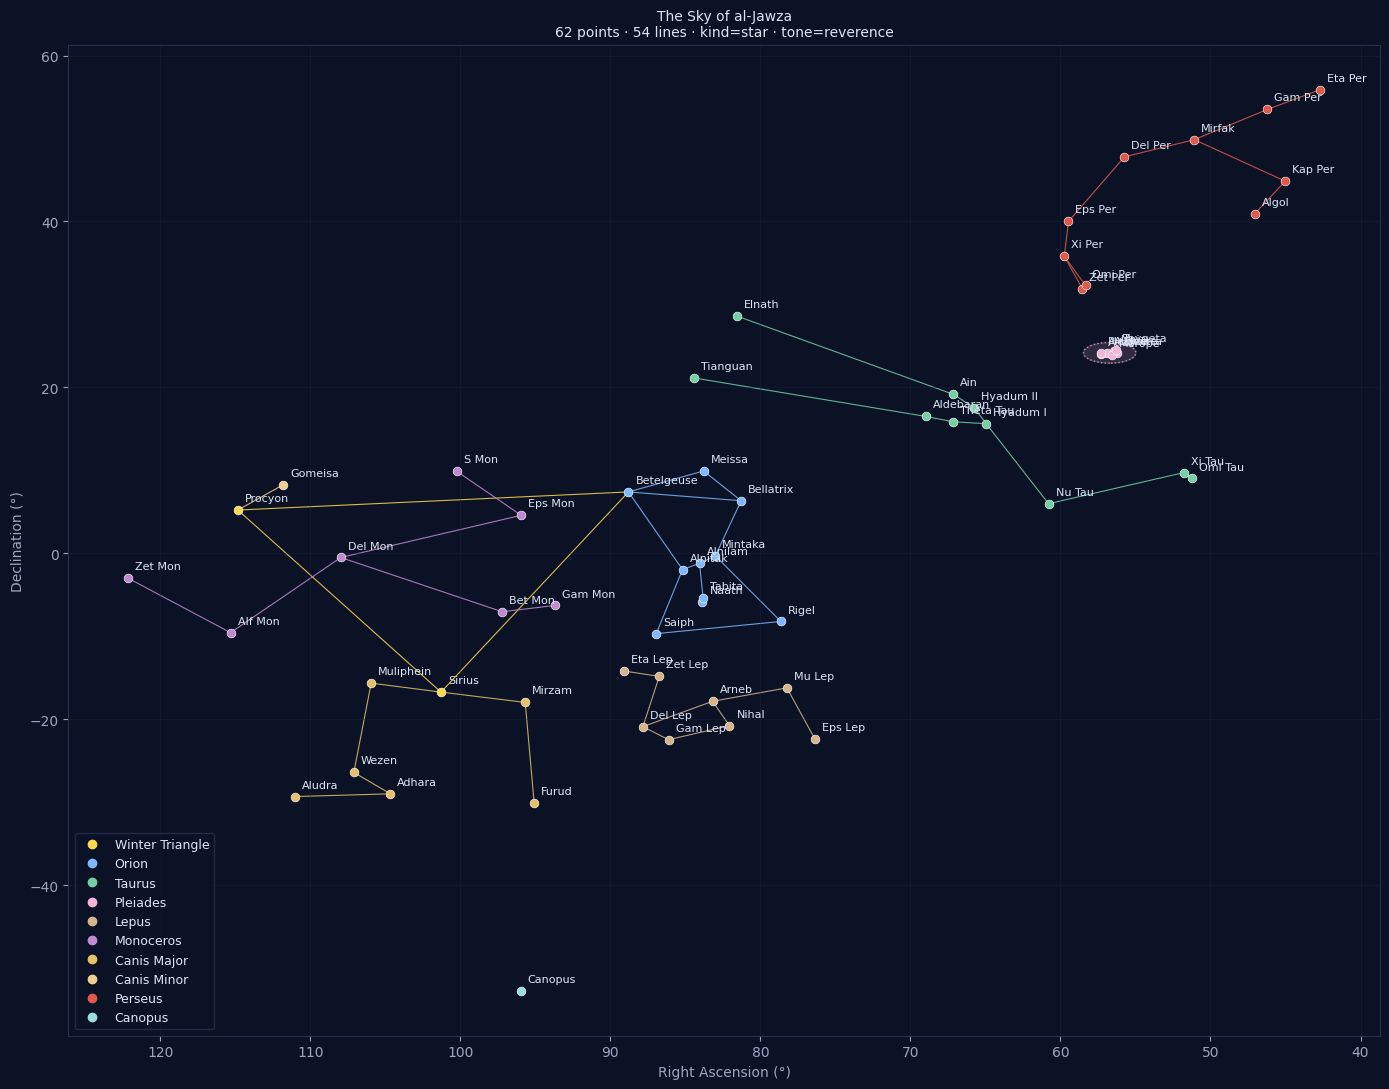

In [30]:
%matplotlib inline
from celestial_render import render_celestial_quipu
fig, ax = render_celestial_quipu(
    recovered_header, recovered_body,
    style={'figsize': (14, 11), 'dpi': 100, 'label_fontsize': 8},
    show_pleiades_halo=True,
)
fig.show()


*The constellation, having descended through the diamond, ascends through the reader. The cord holds. The sky, embroidered in chain, may now be unrolled by any hand that knows where to look.*
